In [7]:
%reload_ext autoreload
%autoreload 2

import sys

from collections import defaultdict

import anndata
import cassiopeia as cas
import matplotlib.pyplot as plt
import mplscience
import numpy as np
import pandas as pd
import pickle as pic
import random
import scanpy as sc
import seaborn as sns
import squidpy as sq
from tqdm.auto import tqdm


SPATIAL_PACKAGE="/path/to/spatial/package"
DATA_DIR="/path/to/kpstpatial/data"
sys.path.append(SPATIAL_PACKAGE)

from utilities import spatial_utilities, target_site_utilities, tree_utilities

from scripts import prepare_infercnv

from IPython.display import Image


## Extended Data Figure 6c

In [13]:
### Prepare Slide-seq

SAMPLE='M11_14'
gene_ordering_file = f'{SPATIAL_PACKAGE}/data/mm10_gene_ordering_sorted.tsv'

adata_path = f'{DATA_DIR}/slideseq/expression/{SAMPLE}_adata.h5ad'

prepare_infercnv.prepare_infercnv_inputs(
    adata_path = adata_path,
    sample_name = SAMPLE,
    gene_ordering_file = gene_ordering_file,
    output_directory = './data',
    bin_size = 50
)

### Proceed to running the infercnv script ###

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/scanpy/preprocessing/_qc.py:428: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]
/orcd/data/ki/001/lab/jones/mgjones/kptc_spatial/KPSpatial-release/reproducibility/Figure3/scripts/prepare_infercnv.py:108: RuntimeWarning: invalid value encountered in scalar divide
  


Detected 5386 spots. Detected a mean UMI count of 10545.727627181583.


### Plotting results

In [25]:
output_directory = f'./data/infercnv/M11_14_pooled/'

adata = sc.read_h5ad(adata_path)
pooled_adata = prepare_infercnv.pool_spots(adata, bin_size=50)

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/scanpy/preprocessing/_qc.py:428: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]
/orcd/data/ki/001/lab/jones/mgjones/kptc_spatial/KPSpatial-release/reproducibility/Figure3/scripts/prepare_infercnv.py:108: RuntimeWarning: invalid value encountered in scalar divide
  
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:892: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['4933401J01Rik', 'Gm26206', 'Xkr4', 'Gm18956', 'Gm37180']

    Inferred to be: categorical

  names = self._prep_dim_index(names

Detected 5386 spots. Detected a mean UMI count of 10545.727627181583.


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


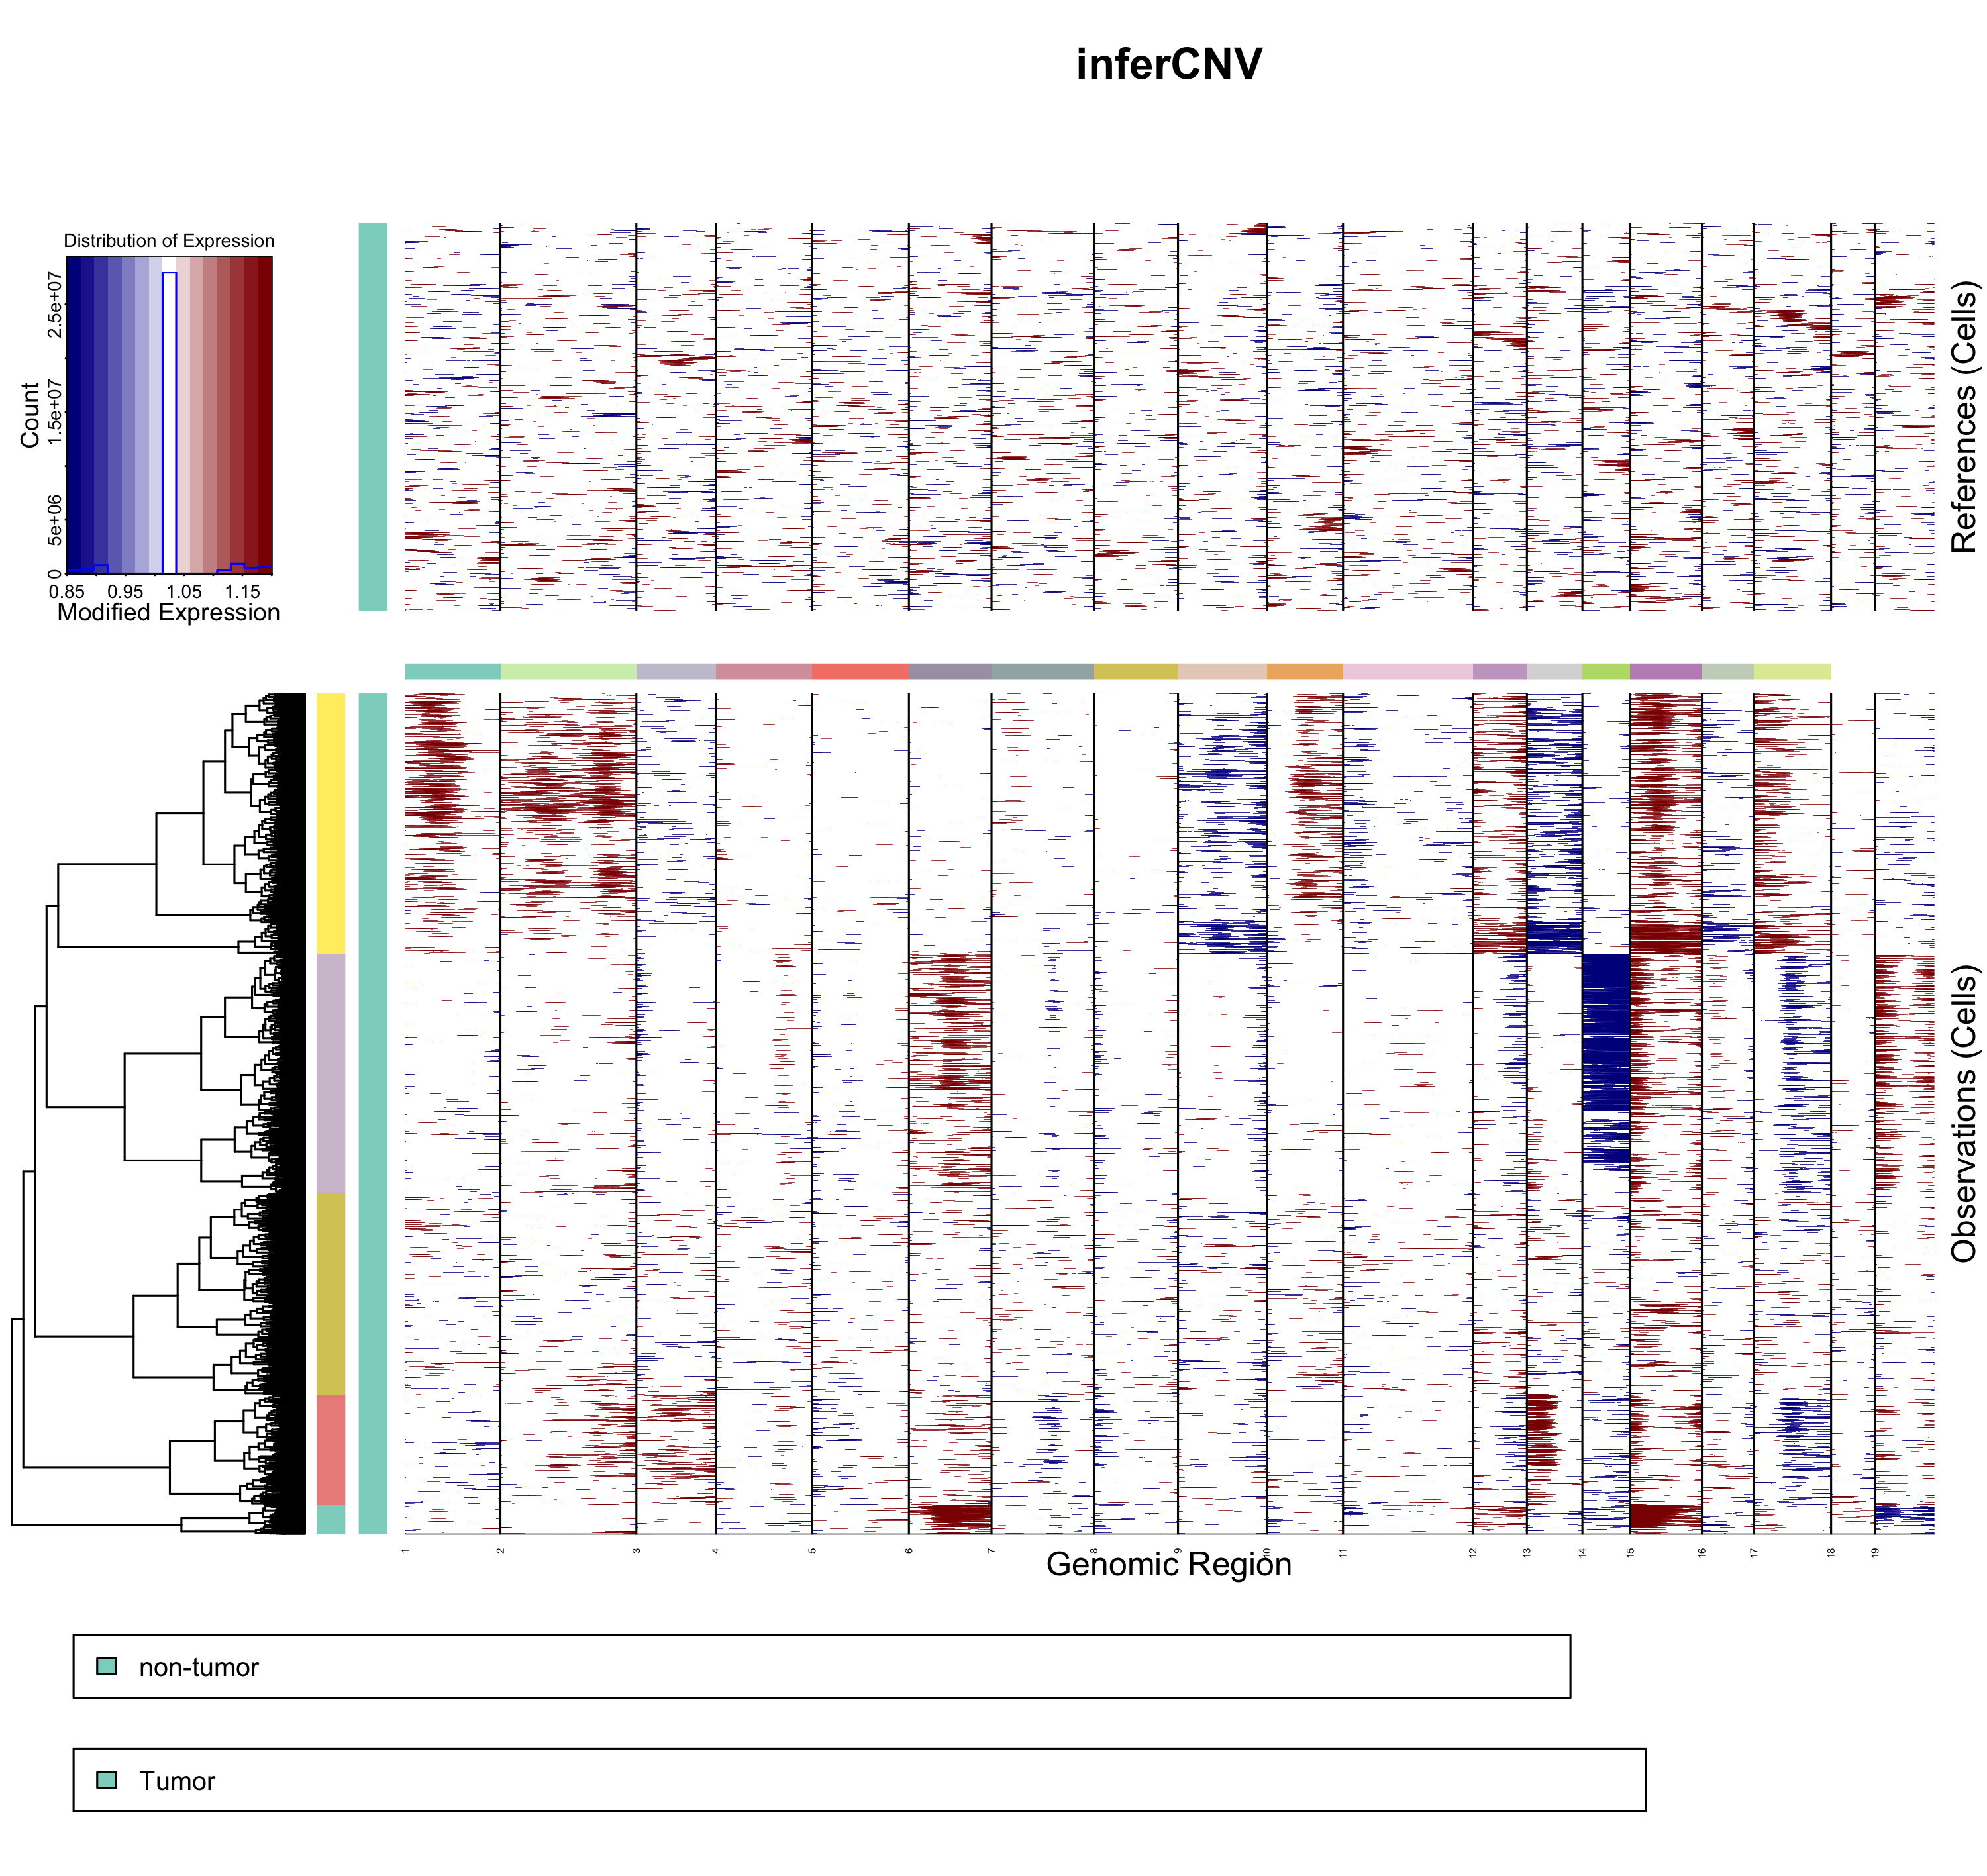

In [28]:
Image(filename=f'{output_directory}/infercnv_clusters.png', width=700)

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


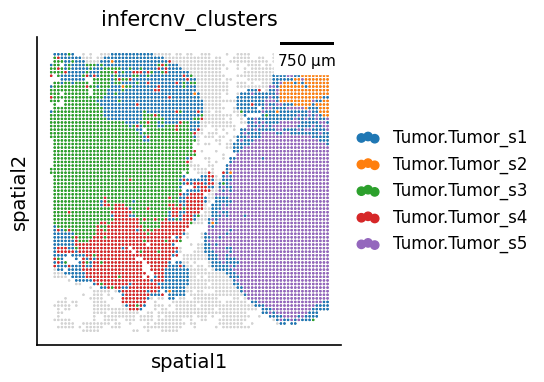

In [27]:
infercnv_groupings = pd.read_csv(f'{output_directory}/17_HMM_predHMMi6.leiden.hmm_mode-subclusters.cell_groupings', sep='\t')

infercnv_groupings.set_index('cell', inplace=True)

infercnv_groupings['cell_group_name2'] = infercnv_groupings.apply(lambda x: 'Normal' if 'Normal' in x.cell_group_name else '.'.join(x.cell_group_name.split(".")[:4]), axis=1)
grouping_counts = infercnv_groupings['cell_group_name2'].value_counts()

filter_groups = grouping_counts[grouping_counts  < 20].index.values

infercnv_groupings.loc[infercnv_groupings['cell_group_name2'].isin(filter_groups), 'cell_group_name2'] = np.nan

infercnv_groupings['cell_group_name2'].value_counts()

pooled_adata.obs['infercnv_clusters'] = None
pooled_adata.obs.loc[infercnv_groupings.index.astype(str), 'infercnv_clusters'] = infercnv_groupings['cell_group_name2'].values

pooled_adata.obs['infercnv_clusters'] = pooled_adata.obs['infercnv_clusters'].astype('category')

with mplscience.style_context():
    fig = plt.figure(figsize=(4,4))
    ax = plt.gca()
    sq.pl.spatial_scatter(pooled_adata, size=2, shape=None, na_color='lightgray', ax=ax, figsize=(4,4), legend_loc=None)
    sq.pl.spatial_scatter(pooled_adata, color=['infercnv_clusters'],
                          groups = [cluster for cluster in pooled_adata.obs['infercnv_clusters'].unique() if 'non-tumor' not in cluster],
                          size=2, ax=ax, shape=None,
                          scalebar_dx=1.0,
                            scalebar_units='um',
                            scalebar_kwargs={"scale_loc": "bottom", "location": "upper right"},
                         )
    plt.gca().invert_yaxis()
    plt.show()

## R code

In [11]:
infercnvObj <- readRDS("/path/ot/infercnv_obj")

In [12]:
dim(infercnvObj@expr.data)

[1] 7249 5386

In [26]:
cluster.3 <- infercnvObj@tumor_subclusters$subclusters$Tumor$Tumor_s3
cluster.5 <- infercnvObj@tumor_subclusters$subclusters$Tumor$Tumor_s1

true.value <- wilcox.test(infercnvObj@expr.data['Kras', cluster.3], infercnvObj@expr.data['Kras', cluster.5], alternative = 'greater')$statistic

all.values <- c(cluster.3, cluster.5)
permutation.test <- 0
for (iter in 1:1000) {

    shuffled.3.indices <- sample(1:length(all.values), size = length(cluster.3))
    shuffled.5.indices <- setdiff(1:length(all.values), shuffled.3.indices)

    shuffled.3 <- all.values[shuffled.3.indices]
    shuffled.5 <- all.values[shuffled.5.indices]
    
    random.value <- wilcox.test(infercnvObj@expr.data['Kras', shuffled.3], infercnvObj@expr.data['Kras', shuffled.5], alternative = 'greater')$statistic

    if (random.value > true.value) {
        permutation.test <- 1 + permutation.test
    }
    
}

print(paste0('Permutation p.value: ', round(permutation.test / 1000)))
# wilcox.test(infercnvObj@expr.data['Kras', cluster.3], infercnvObj@expr.data['Kras', cluster.5], alternative = 'greater')
# infercnvObj@expr.data['Kras',] 

[1] "Permutation p.value: 0"


In [7]:
counts_path = "./data/infercnv/input/M11_14.counts.tsv"
annotation_path = "./data/infercnv/input/M11_14.annotations.tsv"
ordering_path = "../../data/mm10_gene_ordering_sorted.tsv"
controls = "../../data/infercnv_controls.txt"

infercnv_obj = infercnv::CreateInfercnvObject(
    raw_counts_matrix=counts_path,
    annotations_file=annotation_path,
    gene_order_file=ordering_path,
    ref_group_names=c('Normal'),
    delim='\t',
)

INFO [2026-04-08 06:18:04] Parsing matrix: ./data/infercnv/input/M11_14.counts.tsv

INFO [2026-04-08 06:18:32] Parsing gene order file: ../../data/mm10_gene_ordering_sorted.tsv

INFO [2026-04-08 06:18:32] Parsing cell annotations file: ./data/infercnv/input/M11_14.annotations.tsv

INFO [2026-04-08 06:18:32] ::order_reduce:Start.

INFO [2026-04-08 06:18:33] .order_reduce(): expr and order match.

INFO [2026-04-08 06:18:34] ::process_data:order_reduce:Reduction from positional data, new dimensions (r,c) = 26316,5386 Total=52313707 Min=0 Max=1098.

INFO [2026-04-08 06:18:35] num genes removed taking into account provided gene ordering list: 64 = 0.243198054415565% removed.

INFO [2026-04-08 06:18:35] -filtering out cells < 100 or > Inf, removing 0 % of cells

WARN [2026-04-08 06:18:36] Please use "options(scipen = 100)" before running infercnv if you are using the analysis_mode="subclusters" option or you may encounter an error while the hclust is being generated.

INFO [2026-04-08 06:18:

In [8]:
infercnv_hmm = infercnv::run(
    # infercnvObj,
    infercnv_obj,
    min_cells_per_gene=1,
    window_length=101,
    analysis_mode='subclusters',
    hclust_method='ward.D2',
    max_centered_threshold=NA,
    cutoff=0.1,
    out_dir="./data/infercnv/output/",
    cluster_by_groups=TRUE,
    denoise=TRUE,
    HMM=TRUE,
    BayesMaxPNormal=0.5,
    leiden_resolution=0.0005,
    num_threads=10,
    resume_mode=FALSE,
    no_plot=FALSE,
    plot_steps=TRUE,
    write_phylo=TRUE,
)

INFO [2026-04-08 06:27:12] ::process_data:Start

INFO [2026-04-08 06:27:12] 

	STEP 1: incoming data


INFO [2026-04-08 06:27:33] 

	STEP 02: Removing lowly expressed genes


INFO [2026-04-08 06:27:33] ::above_min_mean_expr_cutoff:Start

INFO [2026-04-08 06:27:33] Removing 16788 genes from matrix as below mean expr threshold: 0.1

INFO [2026-04-08 06:27:33] validating infercnv_obj

INFO [2026-04-08 06:27:33] There are 9464 genes and 5386 cells remaining in the expr matrix.

INFO [2026-04-08 06:27:34] no genes removed due to min cells/gene filter

INFO [2026-04-08 06:27:48] 

	STEP 03: normalization by sequencing depth


INFO [2026-04-08 06:27:48] normalizing counts matrix by depth

INFO [2026-04-08 06:27:49] Computed total sum normalization factor as median libsize: 8963.500000

INFO [2026-04-08 06:27:49] Adding h-spike

INFO [2026-04-08 06:27:49] -hspike modeling of Normal

INFO [2026-04-08 06:28:38] validating infercnv_obj

INFO [2026-04-08 06:28:38] normalizing counts matrix by dept